In [1]:
##Experiment: Polynomial Regression on Auto MPG Dataset
# Predict of MPG using Engine Displacemnet
#============================================================
#Step1:Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
#Load Auto MPG dataset

In [5]:
url="https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df=pd.read_csv(url)

In [6]:
#Display first five rows

In [7]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [8]:
#Separate input and output

In [9]:
x=df[['displacement']]
y=df['mpg']

In [10]:
#Check missing values

In [11]:
print("Missing values in ", x.isnull().sum())
print("Missing values in mpg ", y.isnull().sum())

Missing values in  displacement    0
dtype: int64
Missing values in mpg  0


In [12]:
#Remove rows containing missing values

In [13]:
data=df[['displacement','mpg']].dropna()

In [14]:
#Update input and output

In [15]:
x=data[['displacement']]
y=data['mpg']

In [16]:
#Dsiplay the selected data

In [17]:
print("Feature: ")
print(x.head())
print("\nTarget:  ")
print(y.head())

Feature: 
   displacement
0         307.0
1         350.0
2         318.0
3         304.0
4         302.0

Target:  
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


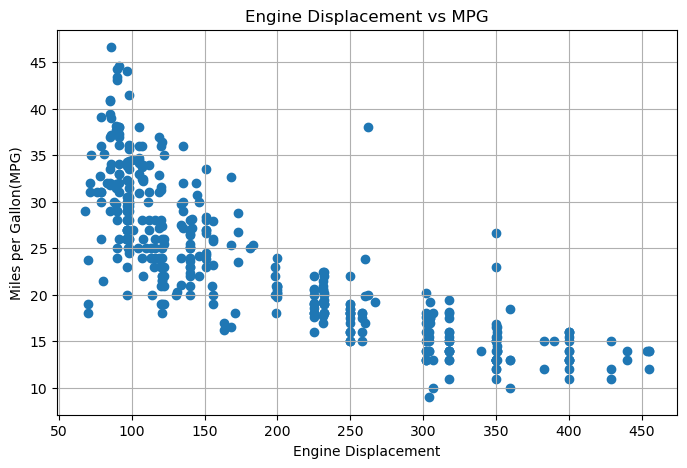

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(x,y)
plt.xlabel("Engine Displacement")
plt.ylabel("Miles per Gallon(MPG)")
plt.title("Engine Displacement vs MPG")
plt.grid(True)
plt.show()

In [19]:
#Split the dataset

In [20]:
x_train, x_test, y_train, y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=38
)
print("Training samples: ", len(x_train))
print("Testing samples: ", len(x_test))

Training samples:  318
Testing samples:  80


In [21]:
#Create Linear Regression Model

In [22]:
linear_model=LinearRegression()

In [23]:
#Train the model

In [24]:
linear_model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
#Predict on test data

In [26]:
y_pred_linear=linear_model.predict(x_test)

In [27]:
#Calculate MSE

In [28]:
mse_linear=mean_squared_error(y_test,y_pred_linear)

In [29]:
#Calculate R-squared

In [30]:
r2_linear=r2_score(y_test,y_pred_linear)

In [31]:
print("Linear Regression Results")
print("-------------------------")
print("MSE: ",mse_linear)
print("R-squared: ",r2_linear)

Linear Regression Results
-------------------------
MSE:  26.700041943371822
R-squared:  0.5761514517085644


In [32]:
#Store results

In [33]:
results=[]

In [34]:
#Store polynomial models for plotting

In [35]:
polynomial_models={}

In [36]:
#Add Linear Regression results

In [37]:
results.append({
    'Model':'Linear Regression',
    'Degree':1,
    'MSE':mse_linear,
    'R-squared':r2_linear
})

In [38]:
#Try polynomial degrees from 2 to 5

In [39]:
for degree in range(2,6):
    #Create polynomial features
    poly=PolynomialFeatures(degree=degree)
    #Transform training and testing data
    x_train_poly=poly.fit_transform(x_train)
    x_test_poly=poly.transform(x_test)
    #Create linear Regression Model
    poly_model=LinearRegression()
    #Train polynomial regression model
    poly_model.fit(x_train_poly,y_train)
    #Make predictions
    y_pred_poly=poly_model.predict(x_test_poly)
    #Calculate evaluation metrics
    mse=mean_squared_error(y_test,y_pred_poly)
    r2=r2_score(y_test,y_pred_poly)
    #Store results
    results.append({
        'Model':'Polynomial Regression',
        'Degree':degree,
        'MSE': mse,
        'R-squared': r2
    })
    #Store model and polynomial transformer
    polynomial_models[degree]={
        'poly':poly,
        'model':poly_model }

In [40]:
#Convert results into Dataframe

In [41]:
results_df=pd.DataFrame(results)

In [42]:
#Display results

In [43]:
results_df

,Model,Degree,MSE,R-squared
0,Linear Regression,1,26.700042,0.576151
1,Polynomial Regression,2,25.611678,0.593429
2,Polynomial Regression,3,25.424794,0.596395
3,Polynomial Regression,4,25.419545,0.596479
4,Polynomial Regression,5,25.370147,0.597263


In [44]:
print(results_df)

                   Model  Degree        MSE  R-squared
0      Linear Regression       1  26.700042   0.576151
1  Polynomial Regression       2  25.611678   0.593429
2  Polynomial Regression       3  25.424794   0.596395
3  Polynomial Regression       4  25.419545   0.596479
4  Polynomial Regression       5  25.370147   0.597263


In [45]:
#Create smooth X values for plotting

In [46]:
x_plot=pd.DataFrame({
    'displacement':np.linspace(
        x['displacement'].min(),
        x['displacement'].max(),
        300)
})

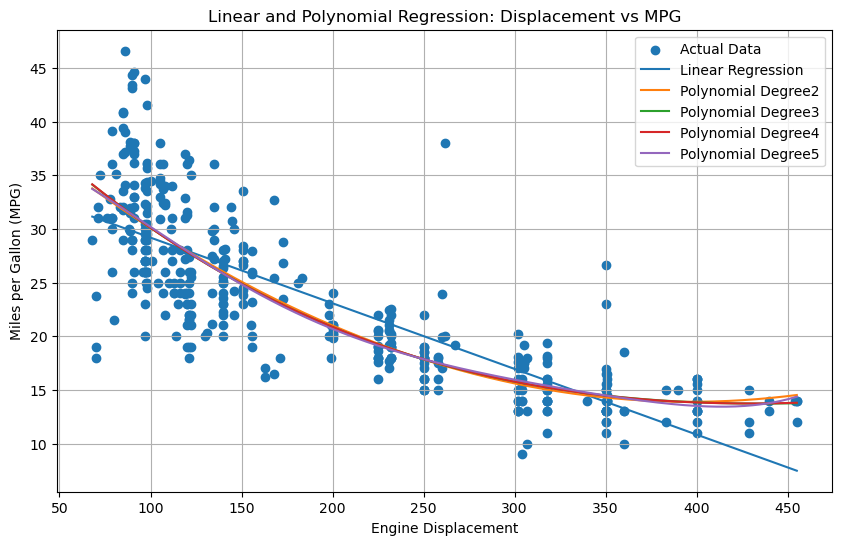

In [47]:
#Creat figure
plt.figure(figsize=(10,6))
#Plot actual data
plt.scatter(
    x['displacement'],
    y,
    label='Actual Data'
)
#----------------------
#Plot Linear Regression
#----------------------
y_plot_linear=linear_model.predict(x_plot)
plt.plot(
    x_plot['displacement'],
    y_plot_linear,
    label='Linear Regression'

)
#-------------------
#Degrees from 2 to 5
#-------------------
for degree in range(2,6):
    #Retieve stored transformer and model
    poly= polynomial_models[degree]['poly']
    poly_model= polynomial_models[degree]['model']
    #Transform smooth x values
    x_plot_poly=poly.transform(x_plot)
    #Predict
    y_plot_poly=poly_model.predict(x_plot_poly)
    #Poly Curve
    plt.plot(
        x_plot['displacement'],
        y_plot_poly,
        label=f'Polynomial Degree{degree}'
    )

#---------------
#Plot formatting
#---------------
plt.xlabel('Engine Displacement')
plt.ylabel('Miles per Gallon (MPG)')
plt.title('Linear and Polynomial Regression: Displacement vs MPG')
plt.legend()
plt.grid(True)
plt.show()

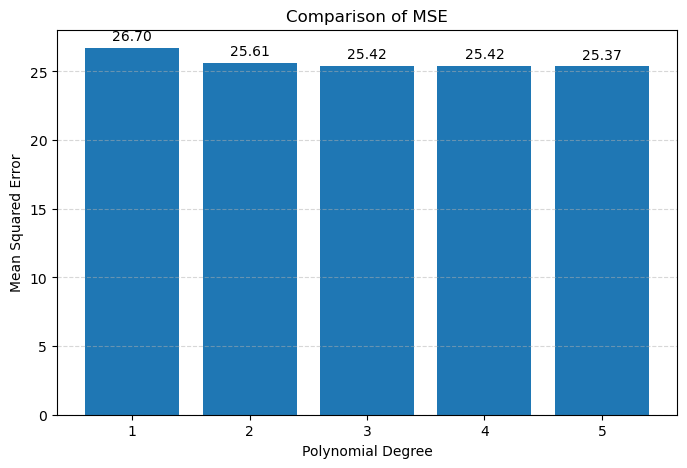

In [48]:
plt.figure(figsize=(8,5))
bars=plt.bar(
    results_df['Degree'].astype(str),
    results_df['MSE']
)
#Add level above bars
plt.bar_label(bars,fmt='%.2f',padding=3)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Comparison of MSE")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

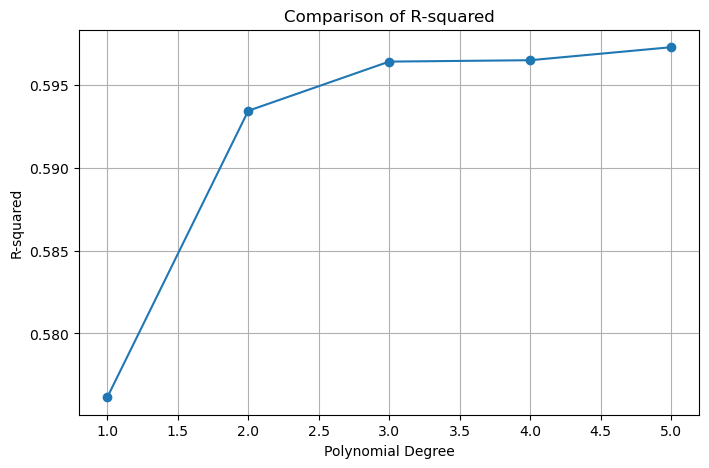

In [49]:
plt.figure(figsize=(8,5))
plt.plot(
    results_df['Degree'],
    results_df['R-squared'],
    marker='o'
)


plt.xlabel("Polynomial Degree")
plt.ylabel("R-squared")
plt.title("Comparison of R-squared")
plt.grid(True)
plt.show()